# 🐍 Python for Data Analysis — Companion Notebook
**Based on:** Ewen Gallic, *Python for Data Analysis* (321 pp.)
🔗 https://egallic.fr/Enseignement/Python/en/_main.pdf

This notebook **covers every chapter** of the book with runnable examples. Open it in Colab and either *Run all*, or step through chapter by chapter.

| Ch | Topic |
|----|-------|
| 1 | Introduction — workspace, variables, comments, modules, help |
| 2 | Types of Data — strings, numbers, booleans, None, dates |
| 3 | Structures — lists, tuples, sets, dictionaries |
| 4 | Operators — arithmetic, comparison, logical |
| 5 | Loading & Saving Data — text, CSV, JSON, Excel |
| 6 | Conditions — `if / if-else / if-elif` |
| 7 | Loops — `while`, `for` |
| 8 | Functions — definition, arguments, scope, lambda, returns |
| 9 | NumPy — arrays, operations, random |
| 10 | Pandas — Series, DataFrames, selection, joins, aggregation |
| 11 | Visualisation — Matplotlib, Seaborn |

In [1]:
# Setup — install anything missing, then import everything we need
import sys, os, subprocess

required = ["numpy", "pandas", "matplotlib", "seaborn", "openpyxl", "pytz"]
missing  = [pkg for pkg in required if not __import__("importlib").util.find_spec(pkg)]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("✅ Environment ready — numpy", np.__version__, "| pandas", pd.__version__)

✅ Environment ready — numpy 1.26.4 | pandas 2.3.3


## 📘 Chapter 1 — Introduction

Python is multiplatform, free, and *interpreted* (no compilation step). Its first public version was released in 1991 by Guido van Rossum. The book recommends **Spyder** or **Jupyter Notebook** as the working environment — Colab is the cloud version of Jupyter.

### 1.1 Variables
Variables are created by assignment. There is no type declaration — Python infers it.

In [2]:
# 1.1 Variable assignment — no type declaration
x = 3              # int
price = 19.99      # float
name  = "Python"   # str
print(x, price, name)
print(type(x), type(price), type(name))

3 19.99 Python
<class 'int'> <class 'float'> <class 'str'>


In [3]:
# 1.1 Deletion of a variable
y = 42
del y
# print(y)   # would raise NameError — variable no longer exists
print("y was deleted successfully")

y was deleted successfully


### 1.2 Naming conventions

- Names start with a letter or underscore, followed by letters/digits/underscores.
- Case-sensitive: `Total` ≠ `total`.
- Reserved words (`for`, `if`, `class`, …) cannot be used as names.
- Conventions: `snake_case` for variables, `UPPER_CASE` for constants, `CamelCase` for classes.

In [4]:
# 1.2 Naming conventions — what's legal vs. idiomatic
total_amount = 1500           # ✅ snake_case — preferred for variables
GST_RATE     = 0.18           # ✅ ALL_CAPS — preferred for constants
firstName    = "Priya"        # works, but camelCase is non-idiomatic in Python
print(total_amount, GST_RATE, firstName)

1500 0.18 Priya


### 1.3 Comments

- `#` starts a single-line comment.
- Triple-quoted strings (three double-quotes in a row) at the top of a file or function are **docstrings**, not comments.

In [5]:
# 1.3 Comments
x = 5   # inline comment after a statement

# Block comment explaining the next operation
y = x ** 2

"""This is technically a docstring (string literal), often used at the top
   of a function or module to document it. Not a comment per se."""
print(x, y)

5 25


### 1.4 Modules & packages

Python ships with a *standard library* (math, datetime, random, os, …). Additional packages (numpy, pandas, matplotlib, …) are installed with `pip` and imported with `import`.

In [6]:
# 1.4 Importing modules — three styles
import math                       # whole module
from math import sqrt, pi         # specific names
import numpy as np                # alias

print(math.cos(0))
print(sqrt(16), pi)
print(np.array([1, 2, 3]))

1.0
4.0 3.141592653589793
[1 2 3]


### 1.5 The help system

- `help(obj)` shows the docstring of a function/class.
- `dir(obj)` lists the attributes/methods available.
- `?` after a name in IPython/Jupyter shows the help inline.

In [7]:
# 1.5 Help system
help(round)            # full help text
print(dir(str)[:8])    # first few methods on str

Help on built-in function round in module builtins:

round(number, ndigits=None)
    Round a number to a given precision in decimal digits.

    The return value is an integer if ndigits is omitted or None.  Otherwise
    the return value has the same type as the number.  ndigits may be negative.

['__add__', '__class__', '__contains__', '__delattr__', '__dir__', '__doc__', '__eq__', '__format__']


## 📘 Chapter 2 — Types of Data

The four basic scalar types are **strings**, **numerical values** (int / float / complex), **booleans**, and the empty object **`None`**. Python also has rich support for **dates and times** via the `datetime` module.

### 2.1 Strings
Strings are sequences of characters enclosed in `'...'` or `"..."` (or `\"\"\"...\"\"\"` for multi-line).

In [8]:
# 2.1.1 Concatenation
greeting = "Hello, " + "Python!"
repeated = "ab" * 3
print(greeting)
print(repeated)

Hello, Python!
ababab


In [9]:
# 2.1.2 Indexing and extraction (slicing)
s = "Aix-Marseille"
print(s[0])           # first char        → 'A'
print(s[-1])          # last char         → 'e'
print(s[4:13])        # slice             → 'Marseille'
print(s[::-1])        # reversed          → 'ellieesraM-xiA'

A
e
Marseille
elliesraM-xiA


In [10]:
# 2.1.3 Methods — case
s = "Hello World"
print(s.upper())      # HELLO WORLD
print(s.lower())      # hello world
print(s.title())      # Hello World
print("PYTHON".swapcase())

HELLO WORLD
hello world
Hello World
python


In [11]:
# 2.1.3 Methods — search patterns
sentence = "Python is a great language for data analysis"
print(sentence.find("great"))      # → index 12  (-1 if not found)
print(sentence.count("a"))          # → 6
print("PY" in sentence.upper())     # → True

12
8
True


In [12]:
# 2.1.3 Methods — splitting and joining
csv_line = "Saree,Kurti,Bedsheet,Watch"
items = csv_line.split(",")
print(items)
print(" | ".join(items))

['Saree', 'Kurti', 'Bedsheet', 'Watch']
Saree | Kurti | Bedsheet | Watch


In [13]:
# 2.1.3 Methods — cleaning
raw = "   Aix-Marseille   "
print(repr(raw.strip()))    # both sides
print(repr(raw.lstrip()))   # left only
print(repr(raw.rstrip()))   # right only

'Aix-Marseille'
'Aix-Marseille   '
'   Aix-Marseille'


In [14]:
# 2.1.3 Methods — replacement
sentence = "I love Java"
print(sentence.replace("Java", "Python"))

I love Python


In [15]:
# 2.1.4 Conversion to a string
n = 42
pi = 3.14159
print(str(n) + " is the answer")
print(f"π ≈ {pi:.2f}")     # f-string formatting

42 is the answer
π ≈ 3.14


### 2.2 Numerical values

Python has three numeric types: `int` (whole numbers), `float` (decimal numbers), and `complex` (with imaginary part). Conversions: `int()`, `float()`, `complex()`.

In [16]:
# 2.2 Integers, floats, and complex
i = 42
f = 3.14
c = 2 + 3j
print(i, f, c)
print(type(i), type(f), type(c))

42 3.14 (2+3j)
<class 'int'> <class 'float'> <class 'complex'>


In [17]:
# 2.2.4 Conversions between numeric types
print(int(3.99))         # → 3 (truncates, doesn't round)
print(float(7))          # → 7.0
print(complex(2, 5))     # → (2+5j)
print(int("123"))        # parse int from string
print(float("3.14"))

3
7.0
(2+5j)
123
3.14


### 2.3 Booleans

Two values: `True` and `False`. Result of every comparison.

In [18]:
# 2.3 Booleans
is_open = True
is_paid = False
print(is_open, is_paid)
print(5 > 3, 5 == 5, 5 != 5)

# Implicit boolean evaluation: empty string/list/None/0 are falsy
for v in [0, 0.0, "", [], None, "x", 1]:
    print(repr(v), "→", bool(v))

True False
True True False
0 → False
0.0 → False
'' → False
[] → False
None → False
'x' → True
1 → True


### 2.4 Empty Object (`None`)

`None` represents the absence of a value (different from `0` or `""`).

In [19]:
# 2.4 None
result = None
print(result is None)        # True — preferred test
print(result == None)        # also True but less idiomatic

True
True


### 2.5 Dates and times

The `datetime` module provides `date`, `time`, `datetime`, and `timedelta`. The `pytz` package adds timezone support.

In [20]:
# 2.5.1 datetime — date
import datetime as dt

today = dt.date.today()
specific = dt.date(2026, 4, 28)
print(today, specific)
print("Year:", today.year, "Month:", today.month, "Day:", today.day)

2026-04-28 2026-04-28
Year: 2026 Month: 4 Day: 28


In [21]:
# 2.5.1 datetime — time
t = dt.time(14, 30, 0)
print(t)
print("Hour:", t.hour, "Minute:", t.minute)

14:30:00
Hour: 14 Minute: 30


In [22]:
# 2.5.1 datetime — full datetime
now = dt.datetime.now()
print(now)
print("ISO format:", now.isoformat())
print("Custom format:", now.strftime("%d-%b-%Y %H:%M"))

2026-04-28 11:42:57.362815
ISO format: 2026-04-28T11:42:57.362815
Custom format: 28-Apr-2026 11:42


In [23]:
# 2.5.1 datetime — timedelta (durations)
delta = dt.timedelta(days=30, hours=5)
future = dt.datetime.now() + delta
print("30 days + 5 hours from now:", future)
print("Days between today and 1-Jan-2027:",
      (dt.date(2027, 1, 1) - dt.date.today()).days)

30 days + 5 hours from now: 2026-05-28 16:42:57.368762
Days between today and 1-Jan-2027: 248


In [24]:
# 2.5.2 pytz — timezones
import pytz

ist = pytz.timezone("Asia/Kolkata")
utc = pytz.utc
moment = dt.datetime.now(tz=ist)
print("IST:", moment.strftime("%H:%M %Z"))
print("UTC:", moment.astimezone(utc).strftime("%H:%M %Z"))

IST: 11:42 IST
UTC: 06:12 UTC


## 📘 Chapter 3 — Data Structures

Python provides four built-in collection types:
- **List** — ordered, mutable, allows duplicates: `[...]`
- **Tuple** — ordered, **immutable**, allows duplicates: `(...)`
- **Set** — unordered, mutable, **no duplicates**: `{...}`
- **Dictionary** — key→value pairs, mutable: `{key: value}`

### 3.1 Lists

In [25]:
# 3.1 Lists — creation and extraction
prices = [499, 1299, 2499, 799, 3999]
print(prices)
print("First :", prices[0])
print("Last  :", prices[-1])
print("Slice :", prices[1:4])

[499, 1299, 2499, 799, 3999]
First : 499
Last  : 3999
Slice : [1299, 2499, 799]


In [26]:
# 3.1.2 Modification — replace, add, delete
prices = [499, 1299, 2499]
prices[0] = 599               # replace
prices.append(3999)           # add at end
prices.insert(1, 999)         # insert at index
print(prices)

prices.remove(999)            # remove by value
last = prices.pop()           # remove and return last
print(prices, "popped:", last)

[599, 999, 1299, 2499, 3999]
[599, 1299, 2499] popped: 3999


In [27]:
# 3.1.3 Verifying if a value is present
print(2499 in [499, 1299, 2499])
print(99   in [499, 1299, 2499])

True
False


In [28]:
# 3.1.4 Copying a list (shallow copy)
a = [1, 2, 3]
b = a            # same object — modifying b modifies a!
c = a.copy()     # independent copy
b[0] = 999
print("a =", a)  # changed
print("c =", c)  # unchanged

a = [999, 2, 3]
c = [1, 2, 3]


In [29]:
# 3.1.5 Sorting
nums = [3, 1, 4, 1, 5, 9, 2, 6]
nums.sort()                                 # in place, ascending
print(nums)
nums.sort(reverse=True)
print(nums)
print(sorted([3, 1, 4]))                    # returns new list

[1, 1, 2, 3, 4, 5, 6, 9]
[9, 6, 5, 4, 3, 2, 1, 1]
[1, 3, 4]


### 3.2 Tuples

In [30]:
# 3.2 Tuples — immutable
point = (3, 5)
print(point[0], point[1])

# Tuples can be unpacked
x, y = point
print(x, y)

# Cannot be modified
try:
    point[0] = 10
except TypeError as e:
    print("TypeError:", e)

3 5
3 5
TypeError: 'tuple' object does not support item assignment


### 3.3 Sets

In [31]:
# 3.3 Sets — unordered, no duplicates
fruits = {"apple", "banana", "apple", "cherry"}
print(fruits)                # duplicate "apple" gone

fruits.add("date")
fruits.discard("banana")
print(fruits)

# Belonging test (very fast for sets)
print("apple" in fruits)
print(list(fruits))          # convert to list

{'apple', 'cherry', 'banana'}
{'apple', 'date', 'cherry'}
True
['apple', 'date', 'cherry']


In [32]:
# 3.3 Set operations
a = {"saree", "kurti", "watch"}
b = {"watch", "bedsheet"}
print("Union       :", a | b)
print("Intersection:", a & b)
print("Difference  :", a - b)
print("Symmetric Δ :", a ^ b)

Union       : {'kurti', 'saree', 'watch', 'bedsheet'}
Intersection: {'watch'}
Difference  : {'kurti', 'saree'}
Symmetric Δ : {'kurti', 'saree', 'bedsheet'}


### 3.4 Dictionaries

In [33]:
# 3.4 Dictionaries — key→value pairs
customer = {"name": "Priya", "balance": 45000, "city": "Chennai"}

# Extraction
print(customer["name"])
print(customer.get("phone", "N/A"))   # safe access with default

# Keys, values, items
print(list(customer.keys()))
print(list(customer.values()))
print(list(customer.items()))

Priya
N/A
['name', 'balance', 'city']
['Priya', 45000, 'Chennai']
[('name', 'Priya'), ('balance', 45000), ('city', 'Chennai')]


In [34]:
# 3.4.4 Modification — replace, add, delete
customer = {"name": "Priya", "balance": 45000}
customer["balance"] = 47500           # replace
customer["email"]   = "p@example.com" # add
del customer["balance"]               # delete
print(customer)

{'name': 'Priya', 'email': 'p@example.com'}


In [35]:
# 3.4.3 Search for belonging — checks KEYS, not values
customer = {"name": "Priya", "balance": 45000}
print("name"  in customer)            # → True
print("Priya" in customer)            # → False (not a key)
print("Priya" in customer.values())   # → True

True
False
True


## 📘 Chapter 4 — Operators

### 4.1 Arithmetic operators

In [36]:
# 4.1 Arithmetic — all the basics
print(7 + 3)      # addition         → 10
print(7 - 3)      # subtraction      → 4
print(7 * 3)      # multiplication   → 21
print(7 / 3)      # division         → 2.333...
print(7 // 3)     # floor division   → 2
print(7 % 3)      # modulo           → 1
print(2 ** 10)    # power            → 1024

10
4
21
2.3333333333333335
2
1
1024


In [37]:
# 4.1.8 Operators on strings
print("ab" + "cd")     # concatenation
print("ab" * 3)        # repetition

# 4.1.9 Operators on lists / tuples
print([1, 2] + [3, 4]) # concatenation
print([0] * 5)         # repetition
print((1, 2) * 2)

abcd
ababab
[1, 2, 3, 4]
[0, 0, 0, 0, 0]
(1, 2, 1, 2)


### 4.2 Comparison operators

In [38]:
# 4.2 Comparison — return booleans
print(5 == 5)      # equal
print(5 != 4)      # not equal
print(3 < 5, 5 < 3)
print(3 <= 3, 5 >= 6)
print("abc" == "abc")

True
True
True False
True False
True


### 4.3 Logical operators

In [39]:
# 4.3 Logical — and / or / not
a, b = True, False
print(a and b)     # False
print(a or b)      # True
print(not a)       # False

# Common idiom
salary, score = 32000, 720
eligible = salary > 25000 and score >= 700
print("Loan eligible:", eligible)

False
True
False
Loan eligible: True


### 4.4 Some functions and constants

In [40]:
# 4.4 Common math functions and constants
import math
print(math.pi, math.e)
print(math.sqrt(2))
print(math.log(100, 10))      # log base 10
print(math.exp(1))
print(round(3.7), abs(-5), pow(2, 10))

3.141592653589793 2.718281828459045
1.4142135623730951
2.0
2.718281828459045
4 5 1024


## 📘 Chapter 5 — Loading & Saving Data

Covers reading and writing **text**, **CSV**, **JSON**, and **Excel** files.

### 5.1.1 Text files

In [41]:
# 5.1.1 Write a text file
text = """Aix-Marseille School of Economics
Python for Data Analysis
Companion notebook
"""
with open("notes.txt", "w", encoding="utf-8") as f:
    f.write(text)
print("✅ wrote notes.txt")

✅ wrote notes.txt


In [42]:
# 5.1.1 Read a text file
with open("notes.txt", encoding="utf-8") as f:
    content = f.read()
print(content)

# Or line-by-line
with open("notes.txt", encoding="utf-8") as f:
    for i, line in enumerate(f, 1):
        print(f"L{i}: {line.strip()}")

Aix-Marseille School of Economics
Python for Data Analysis
Companion notebook

L1: Aix-Marseille School of Economics
L2: Python for Data Analysis
L3: Companion notebook


### 5.1.2 CSV files

In [43]:
# 5.1.2 CSV — using the csv module
import csv

# Write
rows = [["Date","Product","Amount"],
        ["2026-04-28","Saree", 2499],
        ["2026-04-28","Kurti", 1299]]
with open("sales.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerows(rows)

# Read
with open("sales.csv", encoding="utf-8") as f:
    for row in csv.reader(f):
        print(row)

['Date', 'Product', 'Amount']
['2026-04-28', 'Saree', '2499']
['2026-04-28', 'Kurti', '1299']


In [44]:
# 5.1.2 CSV — using pandas (much easier for data analysis)
import pandas as pd
df = pd.read_csv("sales.csv")
print(df)
df.to_csv("sales_back.csv", index=False)

         Date Product  Amount
0  2026-04-28   Saree    2499
1  2026-04-28   Kurti    1299


### 5.1.3 JSON files

In [45]:
# 5.1.3 JSON — write and read
import json

data = {
    "college": "SDNB Vaishnav",
    "city"   : "Chennai",
    "courses": ["Python", "Statistics", "Accounting"],
}

with open("config.json", "w", encoding="utf-8") as f:
    json.dump(data, f, indent=2)

with open("config.json", encoding="utf-8") as f:
    loaded = json.load(f)
print(loaded)
print("First course:", loaded["courses"][0])

{'college': 'SDNB Vaishnav', 'city': 'Chennai', 'courses': ['Python', 'Statistics', 'Accounting']}
First course: Python


### 5.1.4 Excel files

In [46]:
# 5.1.4 Excel — pandas + openpyxl
import pandas as pd
df = pd.DataFrame({
    "Product": ["Saree", "Kurti", "Watch"],
    "Price"  : [2499, 1299, 3499],
    "Stock"  : [10, 25, 4],
})
df.to_excel("inventory.xlsx", index=False)
loaded = pd.read_excel("inventory.xlsx")
print(loaded)

  Product  Price  Stock
0   Saree   2499     10
1   Kurti   1299     25
2   Watch   3499      4


## 📘 Chapter 6 — Conditions

### 6.1 The `if` statement
A block runs only when its condition is true. **Indentation defines the block** in Python.

In [47]:
# 6.1 if alone
x = 10
if x > 5:
    print("x is greater than 5")
print("Always runs")

x is greater than 5
Always runs


In [48]:
# 6.2 if / else
score = 65
if score >= 50:
    print("Pass")
else:
    print("Fail")

Pass


In [49]:
# 6.3 if / elif / else — stepped buckets
percentage = 72
if percentage >= 90:
    grade = "O"
elif percentage >= 75:
    grade = "A+"
elif percentage >= 60:
    grade = "A"
elif percentage >= 50:
    grade = "B+"
else:
    grade = "Fail"
print(f"{percentage}% → Grade {grade}")

72% → Grade A


In [50]:
# 6.x Inline ternary expression — short alternative
x = 10
label = "positive" if x > 0 else "non-positive"
print(label)

positive


## 📘 Chapter 7 — Loops

### 7.1 `while` loop
Runs **as long as** the condition is true.

In [51]:
# 7.1 while
n = 1
while n <= 5:
    print(n)
    n += 1
print("done")

1
2
3
4
5
done


In [52]:
# 7.1 break and continue inside while
i = 0
while True:
    i += 1
    if i % 2 == 0:
        continue           # skip even numbers
    if i > 9:
        break              # stop entirely
    print(i)

1
3
5
7
9


### 7.2 `for` loop — iterates over a sequence

In [53]:
# 7.2 for over a list
for fruit in ["apple", "banana", "cherry"]:
    print(fruit)

apple
banana
cherry


In [54]:
# 7.2 for over range — most common pattern
for i in range(5):           # 0..4
    print(i, end=" ")
print()
for i in range(2, 11, 2):    # even numbers 2..10
    print(i, end=" ")
print()

0 1 2 3 4 
2 4 6 8 10 


In [55]:
# 7.2 for with enumerate (index + value)
months = ["Jan", "Feb", "Mar"]
for idx, m in enumerate(months, start=1):
    print(idx, m)

1 Jan
2 Feb
3 Mar


In [56]:
# 7.2 for over a dictionary
prices = {"saree": 2499, "kurti": 1299, "watch": 3499}
for product, price in prices.items():
    print(product, "→", price)

saree → 2499
kurti → 1299
watch → 3499


## 📘 Chapter 8 — Functions

A function is a reusable named block of code. Defined with `def`.

### 8.1 Definition

In [57]:
# 8.1 Basic definition
def square(x):
    return x * x

print(square(7))

49


In [58]:
# 8.1.1 Adding a docstring
def square(x):
    """Return the square of x."""
    return x * x

help(square)         # docstring shows up in help()

Help on function square in module __main__:

square(x)
    Return the square of x.



### 8.1.2 Argument forms

In [59]:
# 8.1.2 Call without argument names → positional
def divide(a, b):
    return a / b

print(divide(10, 2))            # positional
print(divide(b=2, a=10))        # by keyword (any order)

5.0
5.0


In [60]:
# 8.1.2 Default values + keyword arguments
def greet(name, greeting="Hello"):
    return f"{greeting}, {name}!"

print(greet("Priya"))
print(greet("Arun", greeting="Hi"))

Hello, Priya!
Hi, Arun!


In [61]:
# 8.1.2 Function as an argument to another function
def apply(func, value):
    return func(value)

print(apply(square, 5))
print(apply(str.upper, "python"))

25
PYTHON


### 8.2 Scope

In [62]:
# 8.2 Local vs global scope
x = 10                # global

def f():
    x = 99            # local — does NOT change global
    print("inside :", x)

f()
print("outside:", x)

inside : 99
outside: 10


### 8.3 Lambda functions — small anonymous functions

In [63]:
# 8.3 Lambda
add = lambda a, b: a + b
print(add(2, 3))

# Common use: as the key= argument to sorted/min/max
records = [("Saree", 2499), ("Kurti", 1299), ("Watch", 3499)]
print(sorted(records, key=lambda r: r[1]))

5
[('Kurti', 1299), ('Saree', 2499), ('Watch', 3499)]


### 8.4 Returning several values (tuple unpacking)

In [64]:
# 8.4 Multiple returns
def stats(nums):
    return min(nums), max(nums), sum(nums) / len(nums)

mn, mx, avg = stats([3450, 1200, 5400, 2780, 950])
print(f"min={mn}  max={mx}  mean={avg:.1f}")

min=950  max=5400  mean=2756.0


## 📘 Chapter 9 — Introduction to NumPy

NumPy provides the **`ndarray`** — a fast, fixed-type multi-dimensional array. It's the foundation everything else (pandas, scipy, scikit-learn) is built on.

### 9.1 Arrays

In [65]:
# 9.1 Creating arrays
import numpy as np

a = np.array([1, 2, 3, 4])
b = np.array([[1, 2, 3], [4, 5, 6]])
print(a)
print(b)
print("dtype :", a.dtype)
print("shape :", b.shape)

[1 2 3 4]
[[1 2 3]
 [4 5 6]]
dtype : int32
shape : (2, 3)


In [66]:
# 9.1.1 Special creation functions
print(np.zeros(5))
print(np.ones((2, 3)))
print(np.arange(0, 10, 2))            # 0,2,4,6,8
print(np.linspace(0, 1, 5))            # 5 evenly spaced numbers in [0,1]
print(np.eye(3))                       # identity matrix

[0. 0. 0. 0. 0.]
[[1. 1. 1.]
 [1. 1. 1.]]
[0 2 4 6 8]
[0.   0.25 0.5  0.75 1.  ]
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


### 9.1.2 Dimensions, shape, size

In [67]:
# 9.1.2 Dimensions
m = np.array([[1, 2, 3], [4, 5, 6]])
print("ndim :", m.ndim)
print("shape:", m.shape)
print("size :", m.size)

ndim : 2
shape: (2, 3)
size : 6


### 9.1.3 Extracting elements

In [68]:
# 9.1.3 Indexing & slicing
a = np.arange(10) ** 2
print(a)
print(a[3])
print(a[2:5])
print(a[::-1])

m = np.arange(12).reshape(3, 4)
print(m)
print("m[1,2]   =", m[1, 2])
print("row 0    =", m[0, :])
print("col 1    =", m[:, 1])
print("submatrix=\n", m[0:2, 1:3])

[ 0  1  4  9 16 25 36 49 64 81]
9
[ 4  9 16]
[81 64 49 36 25 16  9  4  1  0]
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
m[1,2]   = 6
row 0    = [0 1 2 3]
col 1    = [1 5 9]
submatrix=
 [[1 2]
 [5 6]]


In [69]:
# 9.1.3 Boolean indexing
a = np.array([10, 25, 7, 42, 13, 99])
print(a > 20)            # boolean mask
print(a[a > 20])         # keep only matching values

[False  True False  True False  True]
[25 42 99]


### 9.1.7 Operations on arrays — vectorised math, no loops needed

In [70]:
# 9.1.7 Element-wise operations
a = np.array([1, 2, 3, 4])
b = np.array([10, 20, 30, 40])
print(a + b)
print(a * b)
print(a ** 2)
print(b / a)

[11 22 33 44]
[ 10  40  90 160]
[ 1  4  9 16]
[10. 10. 10. 10.]


In [71]:
# 9.1.7.4 Matrix operations
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])
print("Element-wise A * B:\n", A * B)
print("Matrix product A @ B:\n", A @ B)
print("Transpose:\n", A.T)
print("Determinant:", np.linalg.det(A))
print("Inverse:\n", np.linalg.inv(A))

Element-wise A * B:
 [[ 5 12]
 [21 32]]
Matrix product A @ B:
 [[19 22]
 [43 50]]
Transpose:
 [[1 3]
 [2 4]]
Determinant: -2.0000000000000004
Inverse:
 [[-2.   1. ]
 [ 1.5 -0.5]]


### 9.1.10 Universal functions and statistics

In [72]:
# 9.1.10 ufuncs and statistical methods
a = np.arange(1, 11)
print("sum  :", a.sum())
print("mean :", a.mean())
print("std  :", a.std())
print("min  :", a.min(), "max:", a.max())
print("argmax:", a.argmax(), "argmin:", a.argmin())
print("cumsum:", a.cumsum())
print("sqrt :", np.sqrt(a))

sum  : 55
mean : 5.5
std  : 2.8722813232690143
min  : 1 max: 10
argmax: 9 argmin: 0
cumsum: [ 1  3  6 10 15 21 28 36 45 55]
sqrt : [1.         1.41421356 1.73205081 2.         2.23606798 2.44948974
 2.64575131 2.82842712 3.         3.16227766]


### 9.2 Pseudo-random numbers

In [73]:
# 9.2 Random numbers — modern API uses np.random.default_rng
rng = np.random.default_rng(seed=42)        # reproducible
print(rng.random(5))                         # uniform [0,1)
print(rng.integers(1, 7, size=10))           # 10 dice rolls
print(rng.normal(loc=100, scale=15, size=5)) # IQ-like normal

[0.77395605 0.43887844 0.85859792 0.69736803 0.09417735]
[4 6 5 5 5 5 4 1 6 3]
[113.19096962 111.66687903 100.99046046 116.9086181  107.01264013]


## 📘 Chapter 10 — Data Manipulation with pandas

pandas builds on NumPy and provides two core structures:
- **`Series`** — a 1-D labelled array
- **`DataFrame`** — a 2-D labelled table (Excel sheet inside Python)

### 10.1.1 Series

In [74]:
# 10.1.1 Creating a Series from a list
import pandas as pd
s = pd.Series([10, 20, 30, 40])
print(s)
print("Default index:", list(s.index))

0    10
1    20
2    30
3    40
dtype: int64
Default index: [0, 1, 2, 3]


In [75]:
# 10.1.1.2 Custom index
s = pd.Series([2499, 1299, 3499],
              index=["saree", "kurti", "watch"],
              name="price")
print(s)
print("Access by label:", s["watch"])

saree    2499
kurti    1299
watch    3499
Name: price, dtype: int64
Access by label: 3499


### 10.1.2 DataFrames

In [76]:
# 10.1.2.1 From a dictionary of columns
df = pd.DataFrame({
    "product": ["Saree", "Kurti", "Watch"],
    "price"  : [2499, 1299, 3499],
    "stock"  : [10, 25, 4],
})
print(df)
print(df.dtypes)
print(df.shape)

  product  price  stock
0   Saree   2499     10
1   Kurti   1299     25
2   Watch   3499      4
product    object
price       int64
stock       int64
dtype: object
(3, 3)


In [77]:
# 10.1.2.5 From a 2-D NumPy array
arr = np.array([[1, 2, 3],
                [4, 5, 6],
                [7, 8, 9]])
df2 = pd.DataFrame(arr, columns=["A", "B", "C"], index=["r1", "r2", "r3"])
print(df2)

    A  B  C
r1  1  2  3
r2  4  5  6
r3  7  8  9


### 10.2 Selection

In [78]:
# 10.2.1 Series — by brackets
s = pd.Series([2499, 1299, 3499], index=["saree", "kurti", "watch"])
print(s["kurti"])
print(s[s > 2000])

# 10.2.1 Series — by .iloc / .loc
print(s.iloc[0])      # by position
print(s.loc["watch"]) # by label

1299
saree    2499
watch    3499
dtype: int64
2499
3499


In [79]:
# 10.2.2 DataFrame — extract a single column
df = pd.DataFrame({"product":["Saree","Kurti","Watch"],
                   "price":[2499, 1299, 3499],
                   "stock":[10, 25, 4]})
print(df["price"])
print(df[["product", "price"]])     # several columns

0    2499
1    1299
2    3499
Name: price, dtype: int64
  product  price
0   Saree   2499
1   Kurti   1299
2   Watch   3499


In [80]:
# 10.2.2 DataFrame — rows by .iloc / .loc
print(df.iloc[0])              # first row
print(df.iloc[0:2])             # first 2 rows
df_idx = df.set_index("product")
print(df_idx.loc["Watch"])      # by label

product    Saree
price       2499
stock         10
Name: 0, dtype: object
  product  price  stock
0   Saree   2499     10
1   Kurti   1299     25
price    3499
stock       4
Name: Watch, dtype: int64


In [81]:
# 10.2.2.4 Boolean mask
print(df[df["price"] > 2000])
print(df[(df["price"] > 1000) & (df["stock"] < 20)])

  product  price  stock
0   Saree   2499     10
2   Watch   3499      4
  product  price  stock
0   Saree   2499     10
2   Watch   3499      4


### 10.3 Renaming columns

In [82]:
# 10.3 Renaming columns
df_renamed = df.rename(columns={"price": "unit_price", "stock": "qty_in_stock"})
print(df_renamed.columns.tolist())

['product', 'unit_price', 'qty_in_stock']


### 10.5 Missing values

In [83]:
# 10.5 Missing values — identify, drop, fill
df_missing = pd.DataFrame({
    "name" : ["A", "B", "C", "D"],
    "score": [85, np.nan, 72, np.nan],
    "city" : ["X", "Y", None, "Z"],
})
print(df_missing.isnull())
print("\nMissing per column:\n", df_missing.isnull().sum())

print("\nAfter dropna:\n", df_missing.dropna())
print("\nAfter fillna:\n", df_missing.fillna({"score": 0, "city": "Unknown"}))

    name  score   city
0  False  False  False
1  False   True  False
2  False  False   True
3  False   True  False

Missing per column:
 name     0
score    2
city     1
dtype: int64

After dropna:
   name  score city
0    A   85.0    X



After fillna:
   name  score     city
0    A   85.0        X
1    B    0.0        Y
2    C   72.0  Unknown
3    D    0.0        Z


### 10.7 Replacing values

In [84]:
# 10.7 Replace specific values
df_replaced = df.replace({"Saree": "Silk Saree", 1299: 1399})
print(df_replaced)

      product  price  stock
0  Silk Saree   2499     10
1       Kurti   1399     25
2       Watch   3499      4


### 10.8 Adding rows / columns

In [85]:
# 10.8.2.3 Add a column derived from existing ones
df = pd.DataFrame({"product":["Saree","Kurti","Watch"],
                   "price":[2499, 1299, 3499],
                   "stock":[10, 25, 4]})
df["value"] = df["price"] * df["stock"]
df["price_with_gst"] = (df["price"] * 1.18).round(2)
print(df)

  product  price  stock  value  price_with_gst
0   Saree   2499     10  24990         2948.82
1   Kurti   1299     25  32475         1532.82
2   Watch   3499      4  13996         4128.82


In [86]:
# 10.8.2.1 Add a row using pd.concat
new_row = pd.DataFrame([{"product":"Bedsheet","price":1199,"stock":12,
                         "value":14388,"price_with_gst":1414.82}])
df_with_new = pd.concat([df, new_row], ignore_index=True)
print(df_with_new)

    product  price  stock  value  price_with_gst
0     Saree   2499     10  24990         2948.82
1     Kurti   1299     25  32475         1532.82
2     Watch   3499      4  13996         4128.82
3  Bedsheet   1199     12  14388         1414.82


### 10.9 Removing duplicates

In [87]:
# 10.9 drop_duplicates
df_dups = pd.DataFrame({"prod":["A","B","A","C","B"], "val":[1,2,1,3,2]})
print(df_dups.drop_duplicates())

  prod  val
0    A    1
1    B    2
3    C    3


### 10.10 Operations & statistics

In [88]:
# 10.10.1 Statistics on a DataFrame
df = pd.DataFrame({
    "Maths"    : [85, 72, 90, 65, 78],
    "Accounts" : [78, 84, 95, 70, 80],
    "Economics": [82, 68, 88, 72, 75],
})
print("describe():\n", df.describe())
print("\nMean per column:", df.mean().tolist())
print("Sum per row     :", df.sum(axis=1).tolist())

describe():
            Maths   Accounts  Economics
count   5.000000   5.000000        5.0
mean   78.000000  81.400000       77.0
std     9.974969   9.154234        8.0
min    65.000000  70.000000       68.0
25%    72.000000  78.000000       72.0
50%    78.000000  80.000000       75.0
75%    85.000000  84.000000       82.0
max    90.000000  95.000000       88.0

Mean per column: [78.0, 81.4, 77.0]
Sum per row     : [245, 224, 273, 207, 233]


### 10.11 Sorting

In [89]:
# 10.11 Sorting
df_sales = pd.DataFrame({
    "product": ["Saree", "Kurti", "Watch", "Bedsheet"],
    "price"  : [2499, 1299, 3499, 1199],
    "qty"    : [10, 25, 4, 12],
})
print(df_sales.sort_values("price", ascending=False))
print(df_sales.sort_values(["qty", "price"], ascending=[False, True]))

    product  price  qty
2     Watch   3499    4
0     Saree   2499   10
1     Kurti   1299   25
3  Bedsheet   1199   12
    product  price  qty
1     Kurti   1299   25
3  Bedsheet   1199   12
0     Saree   2499   10
2     Watch   3499    4


### 10.12 Concatenation

In [90]:
# 10.12 Concatenation
df1 = pd.DataFrame({"a":[1,2], "b":[3,4]})
df2 = pd.DataFrame({"a":[5,6], "b":[7,8]})
print(pd.concat([df1, df2], ignore_index=True))                 # rows
print(pd.concat([df1, df2.rename(columns={"a":"c","b":"d"})], axis=1))  # cols

   a  b
0  1  3
1  2  4
2  5  7
3  6  8
   a  b  c  d
0  1  3  5  7
1  2  4  6  8


### 10.13 Joins (merge)

In [91]:
# 10.13 Joins — like SQL
customers = pd.DataFrame({
    "cust_id": [1, 2, 3, 4],
    "name"   : ["Priya", "Arun", "Kavitha", "Mohan"],
})
orders = pd.DataFrame({
    "cust_id": [1, 1, 3, 5],
    "amount" : [499, 1299, 2499, 3499],
})
inner = customers.merge(orders, on="cust_id", how="inner")
left  = customers.merge(orders, on="cust_id", how="left")
print("Inner join:\n", inner)
print("\nLeft join:\n", left)

Inner join:
    cust_id     name  amount
0        1    Priya     499
1        1    Priya    1299
2        3  Kavitha    2499

Left join:
    cust_id     name  amount
0        1    Priya   499.0
1        1    Priya  1299.0
2        2     Arun     NaN
3        3  Kavitha  2499.0
4        4    Mohan     NaN


### 10.14 Aggregation (groupby)

In [92]:
# 10.14.1 groupby + aggregate
sales = pd.DataFrame({
    "region" : ["Chennai", "Chennai", "Bengaluru", "Madurai", "Chennai"],
    "product": ["Saree", "Kurti", "Saree", "Watch", "Watch"],
    "amount" : [2499, 1299, 1899, 3499, 3299],
})
print(sales.groupby("region")["amount"].sum())
print(sales.groupby("region")["amount"].agg(["sum", "mean", "count"]))
print(sales.groupby(["region", "product"])["amount"].sum())

region
Bengaluru    1899
Chennai      7097
Madurai      3499
Name: amount, dtype: int64


            sum         mean  count
region                             
Bengaluru  1899  1899.000000      1
Chennai    7097  2365.666667      3
Madurai    3499  3499.000000      1
region     product
Bengaluru  Saree      1899
Chennai    Kurti      1299
           Saree      2499
           Watch      3299
Madurai    Watch      3499
Name: amount, dtype: int64


### 10.15–10.16 Data export / import

In [93]:
# 10.15–10.16 Export and re-import a DataFrame
sales.to_csv("sales_demo.csv", index=False)
sales.to_excel("sales_demo.xlsx", index=False)

df_csv  = pd.read_csv("sales_demo.csv")
df_xlsx = pd.read_excel("sales_demo.xlsx")
print("From CSV:\n", df_csv)
print("\nFrom Excel:\n", df_xlsx)

From CSV:
       region product  amount
0    Chennai   Saree    2499
1    Chennai   Kurti    1299
2  Bengaluru   Saree    1899
3    Madurai   Watch    3499
4    Chennai   Watch    3299

From Excel:
       region product  amount
0    Chennai   Saree    2499
1    Chennai   Kurti    1299
2  Bengaluru   Saree    1899
3    Madurai   Watch    3499
4    Chennai   Watch    3299


## 📘 Chapter 11 — Data Visualisation

### 11.1 Matplotlib

Matplotlib's anatomy: every chart is a **Figure** containing one or more **Axes**. Each Axes has data, a title, x/y labels, ticks, and a legend.

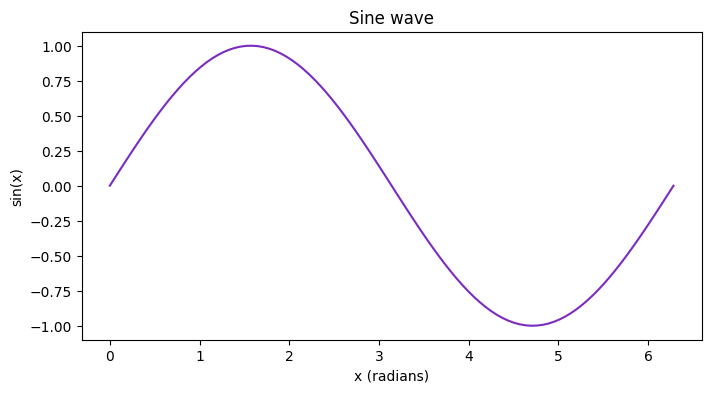

In [94]:
# 11.1.1.1 Lines
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 2 * np.pi, 100)
y = np.sin(x)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, y, color="#7B2CBF")
ax.set_title("Sine wave")
ax.set_xlabel("x (radians)")
ax.set_ylabel("sin(x)")
plt.show()

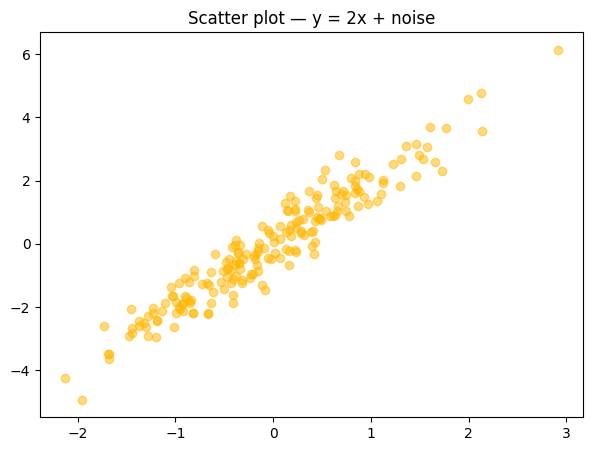

In [95]:
# 11.1.1.2 Scatter plot
rng = np.random.default_rng(42)
x = rng.normal(size=200)
y = 2 * x + rng.normal(scale=0.5, size=200)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x, y, alpha=0.5, color="#FFB703")
ax.set_title("Scatter plot — y = 2x + noise")
plt.show()

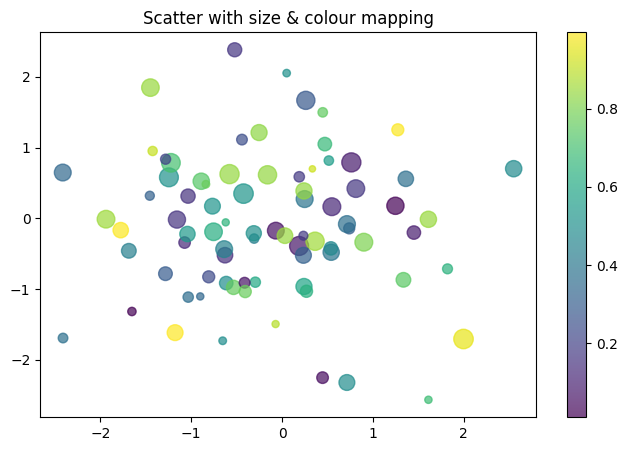

In [96]:
# 11.1.1.3 Size and color encoding
sizes  = rng.uniform(20, 200, 80)
colors = rng.uniform(0, 1, 80)

fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(rng.normal(size=80), rng.normal(size=80),
                s=sizes, c=colors, cmap="viridis", alpha=0.7)
fig.colorbar(sc, ax=ax)
ax.set_title("Scatter with size & colour mapping")
plt.show()

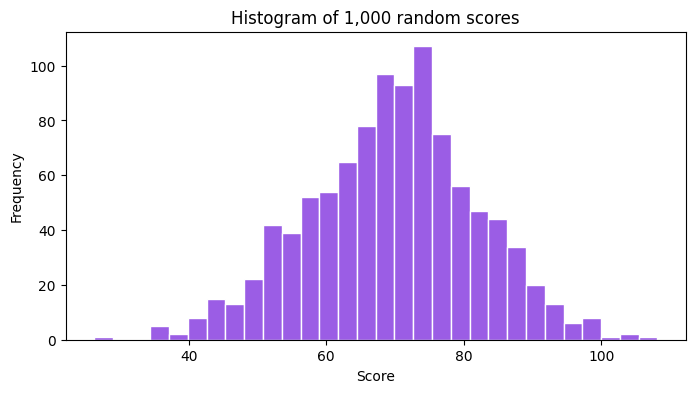

In [97]:
# 11.1.1.4 Histogram
data = rng.normal(loc=70, scale=12, size=1000)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(data, bins=30, color="#9B5DE5", edgecolor="white")
ax.set_title("Histogram of 1,000 random scores")
ax.set_xlabel("Score")
ax.set_ylabel("Frequency")
plt.show()

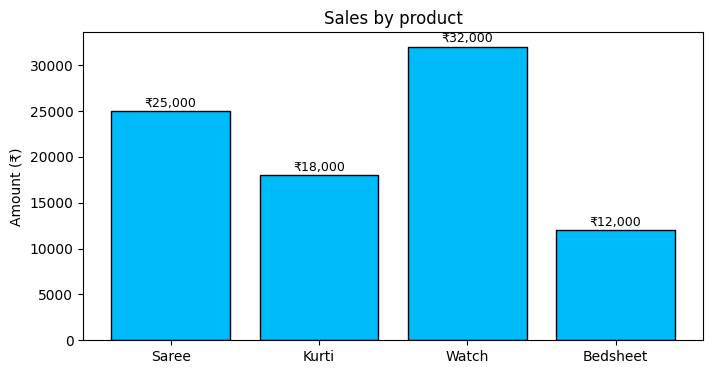

In [98]:
# 11.1.1.5 Bar chart
products = ["Saree", "Kurti", "Watch", "Bedsheet"]
sales    = [25000, 18000, 32000, 12000]
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(products, sales, color="#00BBF9", edgecolor="black")
for b, v in zip(bars, sales):
    ax.text(b.get_x() + b.get_width() / 2, v + 500, f"₹{v:,}",
            ha="center", fontsize=9)
ax.set_title("Sales by product")
ax.set_ylabel("Amount (₹)")
plt.show()

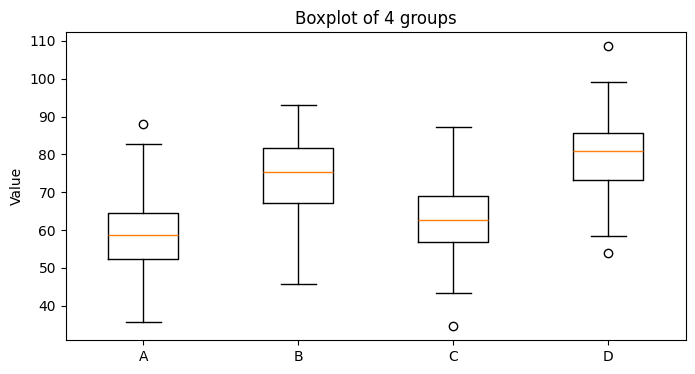

In [99]:
# 11.1.1.6 Boxplot
groups = [rng.normal(loc=m, scale=10, size=100) for m in (60, 75, 65, 80)]
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(groups, labels=["A", "B", "C", "D"])
ax.set_title("Boxplot of 4 groups")
ax.set_ylabel("Value")
plt.show()

### 11.1.2 Several plots on a figure (subplots)

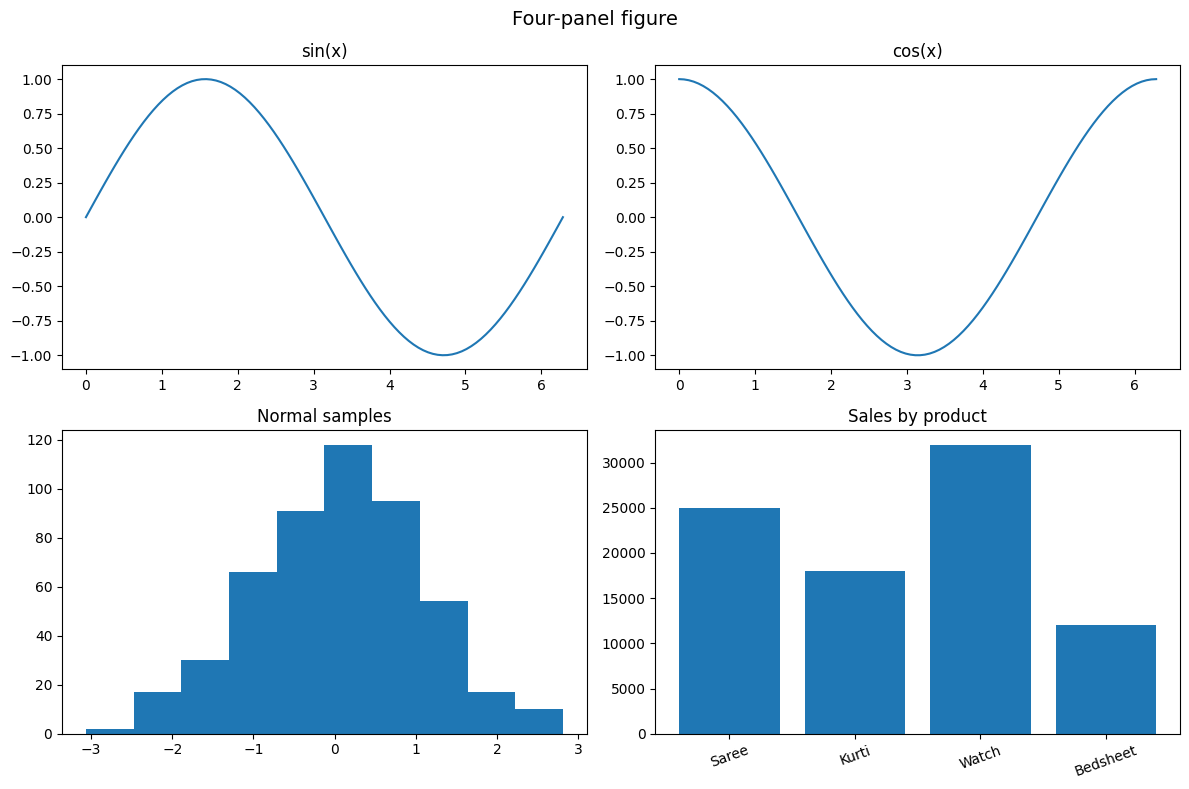

In [100]:
# 11.1.2 Subplots — 2 × 2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Four-panel figure", fontsize=14)

x = np.linspace(0, 2 * np.pi, 100)
axes[0, 0].plot(x, np.sin(x));        axes[0, 0].set_title("sin(x)")
axes[0, 1].plot(x, np.cos(x));        axes[0, 1].set_title("cos(x)")
axes[1, 0].hist(rng.normal(size=500)); axes[1, 0].set_title("Normal samples")
axes[1, 1].bar(products, sales);       axes[1, 1].set_title("Sales by product")
axes[1, 1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

### 11.1.3 Graphic elements — title, axes, legend

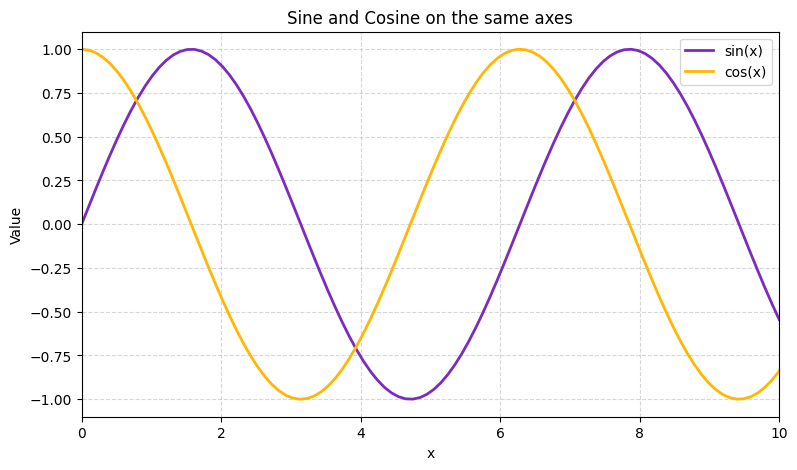

In [101]:
# 11.1.3 Polished version with all elements
x  = np.linspace(0, 10, 100)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, np.sin(x),    label="sin(x)", color="#7B2CBF", linewidth=2)
ax.plot(x, np.cos(x),    label="cos(x)", color="#FFB703", linewidth=2)
ax.set_title("Sine and Cosine on the same axes")
ax.set_xlabel("x")
ax.set_ylabel("Value")
ax.set_xlim(0, 10)
ax.set_ylim(-1.1, 1.1)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(loc="upper right")
plt.show()

### 11.1.5 Exporting graphs

✅ saved chart.png


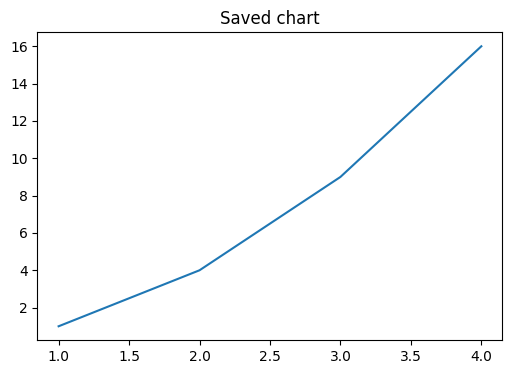

In [102]:
# 11.1.5 Export to a file
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot([1, 2, 3, 4], [1, 4, 9, 16])
ax.set_title("Saved chart")
fig.savefig("chart.png", dpi=150, bbox_inches="tight")
print("✅ saved chart.png")
plt.show()

### 11.2 Graphics with seaborn — statistical visualisation made easy

In [103]:
# 11.2 Seaborn — built on top of matplotlib + pandas-aware
import seaborn as sns
sns.set_theme(style="whitegrid")

# Load a famous example dataset
tips = sns.load_dataset("tips")
print(tips.head())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


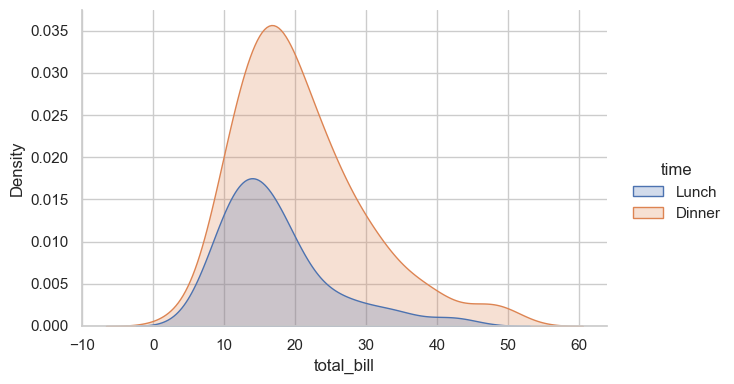

In [104]:
# 11.2 Seaborn — distribution plot
sns.displot(data=tips, x="total_bill", hue="time", kind="kde",
            fill=True, height=4, aspect=1.6)
plt.show()

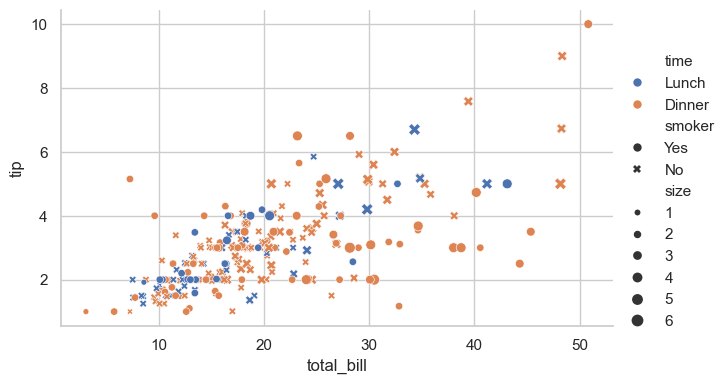

In [105]:
# 11.2 Seaborn — relational plot with categorical hue
sns.relplot(data=tips, x="total_bill", y="tip",
            hue="time", style="smoker", size="size",
            height=4, aspect=1.6)
plt.show()

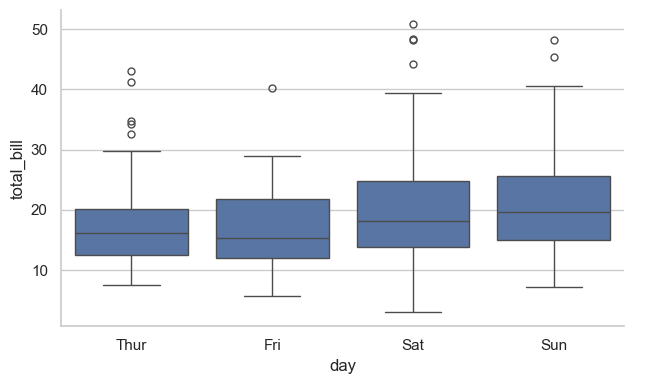

In [106]:
# 11.2 Seaborn — categorical (boxen)
sns.catplot(data=tips, x="day", y="total_bill", kind="box",
            height=4, aspect=1.6)
plt.show()

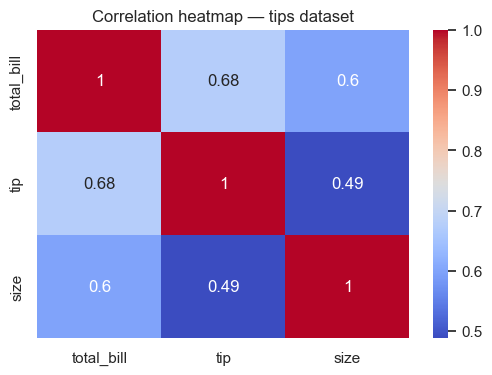

In [107]:
# 11.2 Seaborn — heatmap (correlations)
import pandas as pd
numeric_only = tips.select_dtypes(include="number")
corr = numeric_only.corr()

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", ax=ax)
ax.set_title("Correlation heatmap — tips dataset")
plt.show()

## 🎓 You've covered the whole book

You've now seen working examples for every chapter of *Python for Data Analysis* by Ewen Gallic:

1. ✅ Introduction — workspace, variables, modules, help
2. ✅ Types — strings, numbers, booleans, None, dates
3. ✅ Structures — lists, tuples, sets, dicts
4. ✅ Operators — arithmetic, comparison, logical
5. ✅ Loading & saving data — text, CSV, JSON, Excel
6. ✅ Conditions — if / elif / else
7. ✅ Loops — while, for
8. ✅ Functions — defs, args, scope, lambda, returns
9. ✅ NumPy — arrays, operations, random
10. ✅ pandas — Series, DataFrames, selection, joins, groupby
11. ✅ Visualisation — Matplotlib, Seaborn

Treat this notebook as a **runnable index** — go back to any cell and tweak it to lock in the concept.

In [108]:
# Optional cleanup of demo files we created
import os
for fn in ["notes.txt", "sales.csv", "sales_back.csv", "config.json",
           "inventory.xlsx", "sales_demo.csv", "sales_demo.xlsx", "chart.png"]:
    if os.path.exists(fn):
        os.remove(fn)
print("✅ demo files cleaned up")

✅ demo files cleaned up
